# Analyse univariée et bivariée des données
## TP fil rouge : Parcoursup 2025

**Données** : formations proposées sur Parcoursup en 2025 (ministère de l'Enseignement supérieur, data.enseignementsup-recherche.gouv.fr).

**Organisation** : en binôme, un dépôt GitHub par binôme. Un commit à la fin de chaque partie.

Pour chaque question : du code, **et** une interprétation rédigée. Un chiffre sans phrase ne vaut rien.

---

### 🎯 La question de l'enquête

> **Qu'est-ce qui rend une formation sélective sur Parcoursup ?**

La sélectivité se mesure avec `taux_acces_ens` : la part des candidats qui ont reçu une proposition d'admission. Plus il est **bas**, plus la formation est **sélective**.

Chaque partie du TP fait avancer l'enquête. À la fin de chaque jour, vous rédigez une synthèse : *ce qu'on sait à ce stade sur la sélectivité*. La conclusion finale fait partie du TP noté.

# J1 matin — Comprendre les fondements de l'univarié

## Mise en place

Créez votre dépôt GitHub, clonez-le, placez `parcoursup.csv` dans un dossier `data/`.

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Chargez le fichier (séparateur : `;`). Combien de lignes et de colonnes ?

In [107]:
#chargement des données
df = pd.read_csv('C:\\Users\\PC\\Documents\\python\\Analyse_univariee_bivariee\\parcoursup.csv', sep=';')
# Correction d'une faute de frappe dans l'en-tête du CSV : 'co=ntrat_etab' -> 'contrat_etab'
df = df.rename(columns={'co=ntrat_etab': 'contrat_etab'})
df.head()

C:\Users\PC\AppData\Local\Temp\ipykernel_6472\1412482743.py:2: DtypeWarning: Columns (110: detail_forma2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:\\Users\\PC\\Documents\\python\\Analyse_univariee_bivariee\\parcoursup.csv', sep=';')


,session,contrat_etab,cod_uai,g_ea_lib_vx,dep,dep_lib,region_etab_aff,acad_mies,ville_etab,lib_for_voe_ins,...,tri,cod_aff_form,detail_forma2,lien_form_psup,taux_acces_ens,part_acces_gen,part_acces_tec,part_acces_pro,etablissement_id_paysage,composante_id_paysage
0,2025,Public,0121471J,Institut national universitaire Champollion - ...,12,Aveyron,Occitanie,Toulouse,Rodez,Licence - Sciences et Techniques des Activités...,...,1_universités,2519,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,7.0,93,5,2,NaN,NaN
1,2025,Privé enseignement supérieur,0753605L,FAC LIBRE THEOLOGIE PROTESTANT,75,Paris,Ile-de-France,Paris,Paris 14e Arrondissement,Licence - Théologie - Parcours Théologie prote...,...,1_universités,25320,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,90,5,5,NaN,NaN
2,2025,Privé enseignement supérieur,0951809A,CY ILEPS,95,Val-d'oise,Ile-de-France,Versailles,Cergy,Licence - Sciences de l'éducation et de la for...,...,1_universités,25370,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,77.0,80,16,5,NaN,NaN
3,2025,Public,0922671D,I.U.T de Ville d'Avray - Antenne de Nanterre,92,Hauts-de-Seine,Ile-de-France,Versailles,Nanterre,BUT - Techniques de commercialisation,...,1_universités,25438,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,12.0,48,52,0,NaN,NaN
4,2025,Privé enseignement supérieur,0690195M,Institut Catholique de Lyon,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 2e Arrondissement,Licence - Double diplôme - Licence Droit - Dou...,...,1_universités,25443,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,60.0,100,0,0,NaN,NaN


## 1. Typologie des variables

🎯 *Enquête* : avant de chercher ce qui explique la sélectivité, il faut savoir quelles variables on a et comment les traiter.

Classez au moins ces colonnes : `fili`, `contrat_etab`, `select_form`, `cod_uai`, `capa_fin`, `voe_tot`, `taux_acces_ens`, `pct_bours`. Pour chacune : codage (ce que voit pandas), nature statistique, traitement retenu et justification.

| Variable | Codage | Nature statistique | Traitement retenu | Justification |
|---|---|---|---|---|
|fili |str | | | |

In [152]:
typologie = pd.DataFrame({
    "Variable": ["fili", "contrat_etab", "select_form", "cod_uai", "capa_fin", "voe_tot", "taux_acces_ens", "pct_bours"],
    "Codage pandas": [str(df[c].dtype) for c in ["fili", "contrat_etab", "select_form", "cod_uai", "capa_fin", "voe_tot", "taux_acces_ens", "pct_bours"]],
    "Nature statistique": [
        "qualitative nominale", "qualitative nominale", "qualitative nominale binaire",
        "identifiant", "quantitative discrète", "quantitative discrète",
        "quantitative continue", "quantitative continue"
    ],
    "Traitement retenu": [
        "effectifs / barres", "effectifs / regroupement public-privé", "comparaison de groupes",
        "ne pas résumer comme un nombre", "centre, dispersion, log si besoin", "centre, dispersion, log si besoin",
        "variable cible de sélectivité", "centre, dispersion, histogramme"
    ],
    "Justification": [
        "modalités de filières", "statut de l'établissement", "label sélectif/non sélectif",
        "code administratif sans ordre", "nombre de places", "nombre de demandes",
        "plus le taux est bas, plus la formation est sélective", "pourcentage d'admis boursiers"
    ]
})
typologie

,Variable,Codage pandas,Nature statistique,Traitement retenu,Justification
0,fili,str,qualitative nominale,effectifs / barres,modalités de filières
1,contrat_etab,str,qualitative nominale,effectifs / regroupement public-privé,statut de l'établissement
2,select_form,str,qualitative nominale binaire,comparaison de groupes,label sélectif/non sélectif
3,cod_uai,str,identifiant,ne pas résumer comme un nombre,code administratif sans ordre
4,capa_fin,int64,quantitative discrète,"centre, dispersion, log si besoin",nombre de places
5,voe_tot,int64,quantitative discrète,"centre, dispersion, log si besoin",nombre de demandes
6,taux_acces_ens,float64,quantitative continue,variable cible de sélectivité,"plus le taux est bas, plus la formation est sé..."
7,pct_bours,float64,quantitative continue,"centre, dispersion, histogramme",pourcentage d'admis boursiers


In [108]:
#Typologie des variables
df.dtypes[['fili','contrat_etab', 'select_form', 'cod_uai', 'capa_fin', 'voe_tot', 'taux_acces_ens', 'pct_bours']]

fili                  str
contrat_etab          str
select_form           str
cod_uai               str
capa_fin            int64
voe_tot             int64
taux_acces_ens    float64
pct_bours         float64
dtype: object

> 💾 **Commit** : « Typologie des variables »

## 2. Tendance centrale

🎯 *Enquête* : à quoi ressemble une formation « typique » ? Est-elle sélective ? On regarde d'abord la sélectivité, puis deux causes possibles : la demande (`voe_tot`) et la taille (`capa_fin`).

**2.1** Moyenne et médiane de `taux_acces_ens`. Que remarquez-vous ?

In [109]:
#mediane et moyenne de taux_acces_ens
print ("Moyenne de taux_acces_ens : ", df['taux_acces_ens'].mean())
print ("Médiane de taux_acces_ens : ", df['taux_acces_ens'].median())

Moyenne de taux_acces_ens :  56.14736250614596
Médiane de taux_acces_ens :  54.0


**Interprétation** : _à rédiger_

On remraque que la moyenne et la médiane de taux_acces_ens sont assez proches, nos donnees  ont l'air symetriques à premiere vue.

**2.2** Moyenne et médiane de `voe_tot`. Une formation très demandée sera-t-elle forcément sélective ? Gardez la question en tête.

In [110]:
# mediane et moyenne de voe_tot
print ("Moyenne de voe_tot : ", df['voe_tot'].mean())
print ("Médiane de voe_tot : ", df['voe_tot'].median())


Moyenne de voe_tot :  947.4028206567499
Médiane de voe_tot :  385.0


**Interprétation** : _à rédiger_

On remarque un ecart cataclysmique entre la moyenne et la mediane. Les données sont asymetriques. Les valeurs aberrantes sur les voeux de certaines formations impactent la moyenne.

**2.3** Quelle formation a la plus grande capacité (`capa_fin`) ? Que deviennent la moyenne et la médiane sans elle ?

In [111]:
df[df['capa_fin'] == df['capa_fin'].max()]

,session,contrat_etab,cod_uai,g_ea_lib_vx,dep,dep_lib,region_etab_aff,acad_mies,ville_etab,lib_for_voe_ins,...,tri,cod_aff_form,detail_forma2,lien_form_psup,taux_acces_ens,part_acces_gen,part_acces_tec,part_acces_pro,etablissement_id_paysage,composante_id_paysage
10282,2025,Public,0381629P,CNED,38,Isère,Auvergne-Rhône-Alpes,Grenoble,Grenoble,BTS - Services - Diététique et nutrition - Ent...,...,2_Lycées,20772,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,54,32,14,NaN,NaN


In [112]:
df_sans_capa_fin = df[df['capa_fin'] != df['capa_fin'].max()]
print ("Moyenne de voe_tot (sans capa_fin max) : ", df_sans_capa_fin['voe_tot'].mean())
print ("Médiane de voe_tot (sans capa_fin max) : ", df_sans_capa_fin['voe_tot'].median())


Moyenne de voe_tot (sans capa_fin max) :  947.3560451898112
Médiane de voe_tot (sans capa_fin max) :  385.0


**Interprétation** : _à rédiger_

Les medianes sont les mêmes, et les moyennes aussi sont sensiblement egales. Donc la formation ayant la plus grande capacité n'impacte pas la tendance de notre jeu de données. 

**BTS - Services - Diététique et nutrition - Entièrement en distanciel**

**2.4** Mode de `fili` et de `contrat_etab`.

In [113]:
# Mode de `fili` et de `contrat_etab`
print("Mode de `fili` : ", df['fili'].mode()[0])
print("Mode de `contrat_etab` : ", df['contrat_etab'].mode()[0])

Mode de `fili` :  BTS
Mode de `contrat_etab` :  Public


**Interprétation** : _à rédiger_

On remarque qu'il y a plus de BTS en filière et plus d'établissements publics . 

> 💾 **Commit** : « Tendance centrale »

## 3. Dispersion

🎯 *Enquête* : les formations sont-elles toutes à peu près aussi sélectives, ou y a-t-il de grands écarts à expliquer ?

On étudie la dispersion de `voe_tot` de bout en bout, puis on la compare à `taux_acces_ens`.

**3.1** Étendue de `voe_tot` (minimum, maximum, étendue).

In [114]:
#Etendue de voe_tot(min, max, etendue)
print("Minimum de `voe_tot` : ", df['voe_tot'].min())
print("Maximum de `voe_tot` : ", df['voe_tot'].max())
print("Etendue de `voe_tot` : ", df['voe_tot'].max() - df['voe_tot'].min())

Minimum de `voe_tot` :  1
Maximum de `voe_tot` :  19404
Etendue de `voe_tot` :  19403


**Interprétation** : _à rédiger_

Les données sont dispersées car l'étendue est presque égale au maximum.

**3.2** Variance pas à pas sur les **10 premières formations** : écarts à la moyenne, écarts au carré, somme des écarts. Calculez la variance en divisant par n, puis par n − 1. Vérifiez avec numpy et pandas.

In [115]:
#echantillon aleatoire de 10 observations
df_10 = df.sample(n=10, random_state=76)
df_10

,session,contrat_etab,cod_uai,g_ea_lib_vx,dep,dep_lib,region_etab_aff,acad_mies,ville_etab,lib_for_voe_ins,...,tri,cod_aff_form,detail_forma2,lien_form_psup,taux_acces_ens,part_acces_gen,part_acces_tec,part_acces_pro,etablissement_id_paysage,composante_id_paysage
9917,2025,Public,0570057C,Lycée Robert Schuman,57,Moselle,Grand-Est,Nancy-Metz,Metz,BTS - Services - Commerce International,...,2_Lycées,6530,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,26.0,37,41,23,NaN,NaN
476,2025,Public,0782075G,Unité de Formation et de Recherche de Sciences...,78,Yvelines,Ile-de-France,Versailles,Versailles,Licence - Mathématiques et informatique appliq...,...,1_universités,9988,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,60.0,100,0,0,NaN,NaN
2150,2025,Public,0212296G,Université Bourgogne Europe (ex université de ...,21,Côte-d'Or,Bourgogne-Franche-Comté,Dijon,Dijon,Licence - Administration économique et sociale,...,1_universités,3276,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,98.0,74,21,5,NaN,NaN
6031,2025,Public,0150037J,ENILV - Georges Pompidou,15,Cantal,Auvergne-Rhône-Alpes,Clermont-Ferrand,Aurillac,"BTS - Agricole - QUalité, ALimentation, Innova...",...,2_Lycées,2957,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,73.0,17,67,17,NaN,NaN
9,2025,Public,9740478B,Université de La Réunion - Saint Denis,974,La Réunion,Réunion,La Réunion,Saint-Denis,Licence - Informatique,...,1_universités,26386,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,100.0,67,26,6,NaN,NaN
7294,2025,Public,0270044B,Lycée Georges Dumezil,27,Eure,Normandie,Normandie,Vernon,BTS - Services - Professions immobilières,...,2_Lycées,28819,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,36.0,28,38,34,NaN,NaN
6377,2025,Privé sous contrat d'association,0721381K,MFR-IR de Bernay en Champagne,72,Sarthe,Pays-de-la-Loire,Nantes,Bernay-Neuvy-en-Champagne,"BTS - Agricole - Analyse, conduite et stratégi...",...,2_Lycées,8765,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,88.0,0,17,83,NaN,NaN
3831,2025,Public,0011312W,IUT Lyon1 Site de Bourg-en-Bresse,01,Ain,Auvergne-Rhône-Alpes,Lyon,Bourg-en-Bresse,Licence - Parcours d'Accès Spécifique Santé (P...,...,1_universités,48773,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,27.0,100,0,0,NaN,NaN
5052,2025,Public,0690038S,Lycée La Martinière Duchère,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 9e Arrondissement,CPGE - ECT - Option technologique,...,2_Lycées,8214,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,40.0,0,100,0,NaN,NaN
13843,2025,Public,0561311W,IFSI CH Bretagne Sud Lorient,56,Morbihan,Bretagne,Rennes,Lorient,D.E Infirmier,...,3_Autres formations,23386,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,40.0,48,48,4,NaN,NaN


In [116]:
x0 = 0
x_bar = df_10['voe_tot'].mean()
for e in df_10['voe_tot'].values:
    x0 += (e - x_bar)**2
print("moyenne  : ", x_bar)
print("Somme des carrés des écarts : ", x0)
print("Variance de `voe_tot` avec n-1 : ", x0 / (len(df_10) - 1))
print("Variance de `voe_tot` avec n : ", x0 / len(df_10))



moyenne  :  1270.0
Somme des carrés des écarts :  20952368.0
Variance de `voe_tot` avec n-1 :  2328040.888888889
Variance de `voe_tot` avec n :  2095236.8


**Interprétation** : _à rédiger_

Le resultat de notre variance depend fortement de l'échantllon sélectionné. 

**3.3** Calculez tous les indicateurs de dispersion de `voe_tot` : variance, écart-type, écart absolu moyen, Q1, Q3, IQR, coefficient de variation. Comparez l'écart-type, l'écart absolu moyen et l'IQR.

In [117]:
#calcul de variance, écart-type, écart absolu moyen, Q1, Q3, IQR, coefficient de variation
variance = df['voe_tot'].var()
ecart_type_voe = df['voe_tot'].std()
mad_voe_tot = (df['voe_tot'] - df['voe_tot'].mean()).abs().mean()
Q1 = df['voe_tot'].quantile(0.25)
Q3 = df['voe_tot'].quantile(0.75)
IQR_voe = Q3 - Q1
coefficient_variation_voe = ecart_type_voe / x_bar * 100 if x_bar != 0 else 0

print("Variance de `voe_tot` : ", variance)
print("Ecart-type de `voe_tot` : ", ecart_type_voe)
print("MAD de `voe_tot` : ", mad_voe_tot)
print("Q1 de `voe_tot` : ", Q1)
print("Q3 de `voe_tot` : ", Q3)
print("IQR de `voe_tot` : ", IQR_voe)
print("Coefficient de variation de `voe_tot` : ", coefficient_variation_voe)

Variance de `voe_tot` :  2509634.0870399703
Ecart-type de `voe_tot` :  1584.182466460215
MAD de `voe_tot` :  929.8966075064853
Q1 de `voe_tot` :  160.0
Q3 de `voe_tot` :  1016.0
IQR de `voe_tot` :  856.0
Coefficient de variation de `voe_tot` :  124.73877688663111


**Interprétation** : _à rédiger_

**3.4** Comparez la dispersion de `voe_tot` et de `taux_acces_ens` (écart-type, IQR, coefficient de variation). Laquelle est la plus dispersée ? Qu'est-ce que ça dit des écarts de sélectivité entre formations ?

In [118]:
#calcul de variance, écart-type, écart absolu moyen, Q1, Q3, IQR, coefficient de variation
ecart_type_ens = df['taux_acces_ens'].std()
Q1 = df['taux_acces_ens'].quantile(0.25)
Q3 = df['taux_acces_ens'].quantile(0.75)
IQR_ens = Q3 - Q1
coefficient_variation_ens = ecart_type_ens / x_bar * 100 if x_bar != 0 else 0

print("Ecart-type de `taux_acces_ens` : ", ecart_type_ens)
print("Q1 de `taux_acces_ens` : ", Q1)
print("Q3 de `taux_acces_ens` : ", Q3)
print("IQR de `taux_acces_ens` : ", IQR_ens)
print("Coefficient de variation de `taux_acces_ens` : ", coefficient_variation_ens)

Ecart-type de `taux_acces_ens` :  28.590670547606372
Q1 de `taux_acces_ens` :  33.0
Q3 de `taux_acces_ens` :  81.0
IQR de `taux_acces_ens` :  48.0
Coefficient de variation de `taux_acces_ens` :  2.2512339013863283


In [119]:
#comparaison de la dispersion entre voe_tot et taux_acces_ens
print("Comparaison de la dispersion :")
print("Ecart type de `voe_tot` : ", ecart_type_voe)
print("Ecart type de `taux_acces_ens` : ", ecart_type_ens)
print("IQR de `voe_tot` : ", IQR_voe)
print("IQR de `taux_acces_ens` : ", IQR_ens)
print("Coefficient de variation de `voe_tot` : ", coefficient_variation_voe)
print("Coefficient de variation de `taux_acces_ens` : ", coefficient_variation_ens)


Comparaison de la dispersion :
Ecart type de `voe_tot` :  1584.182466460215
Ecart type de `taux_acces_ens` :  28.590670547606372
IQR de `voe_tot` :  856.0
IQR de `taux_acces_ens` :  48.0
Coefficient de variation de `voe_tot` :  124.73877688663111
Coefficient de variation de `taux_acces_ens` :  2.2512339013863283


**Interprétation** : _à rédiger_

> 💾 **Commit** : « Dispersion »

## 4. Graphiques

🎯 *Enquête* : voir la sélectivité, et trouver un premier indice de ce qui la fait varier.

**4.1** Histogramme de `taux_acces_ens`. À quelle forme vous attendiez-vous ? Qu'obtenez-vous ?

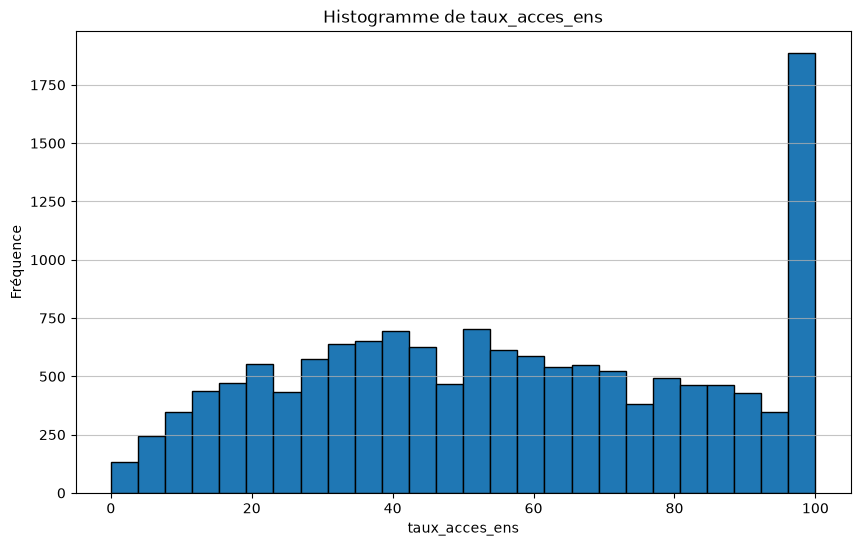

In [120]:
#Histogramme de taux_acces_ens
plt.figure(figsize=(10, 6))
plt.hist(df['taux_acces_ens'], bins='auto', edgecolor='black')  
plt.title('Histogramme de taux_acces_ens')
plt.xlabel('taux_acces_ens')
plt.ylabel('Fréquence')
plt.grid(axis='y', alpha=0.75)

**Interprétation** : _à rédiger_

**4.2** Diagramme en barres de `fili`, trié par effectif.

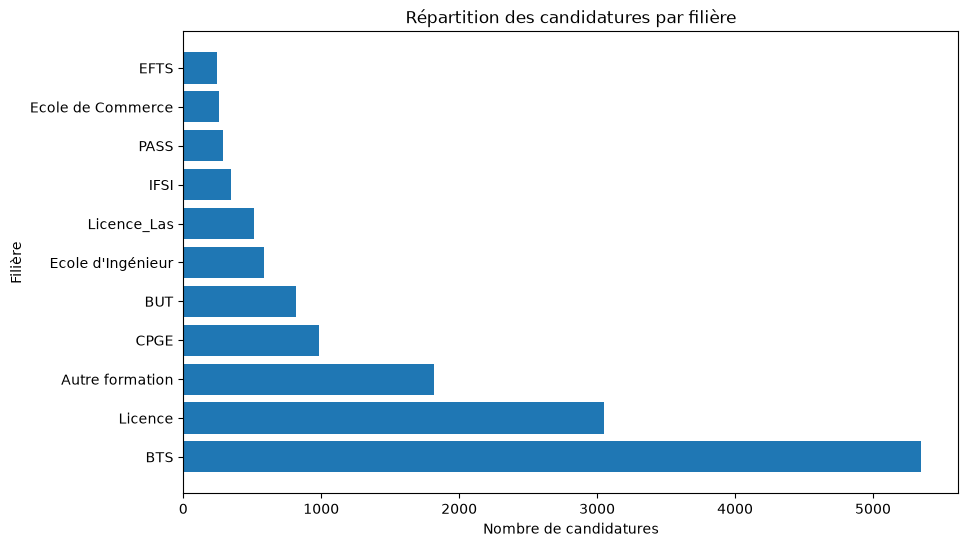

In [121]:
#diagramme en barres horizontal de fili

plt.figure(figsize=(10, 6))
plt.barh(filiere_counts.index, filiere_counts.values)
plt.title('Répartition des candidatures par filière')
plt.xlabel('Nombre de candidatures')
plt.ylabel('Filière')
plt.show()

**4.2 bis** Camembert de `contrat_etab`, puis camembert de `fili`. Lequel est lisible ? Pourquoi ?

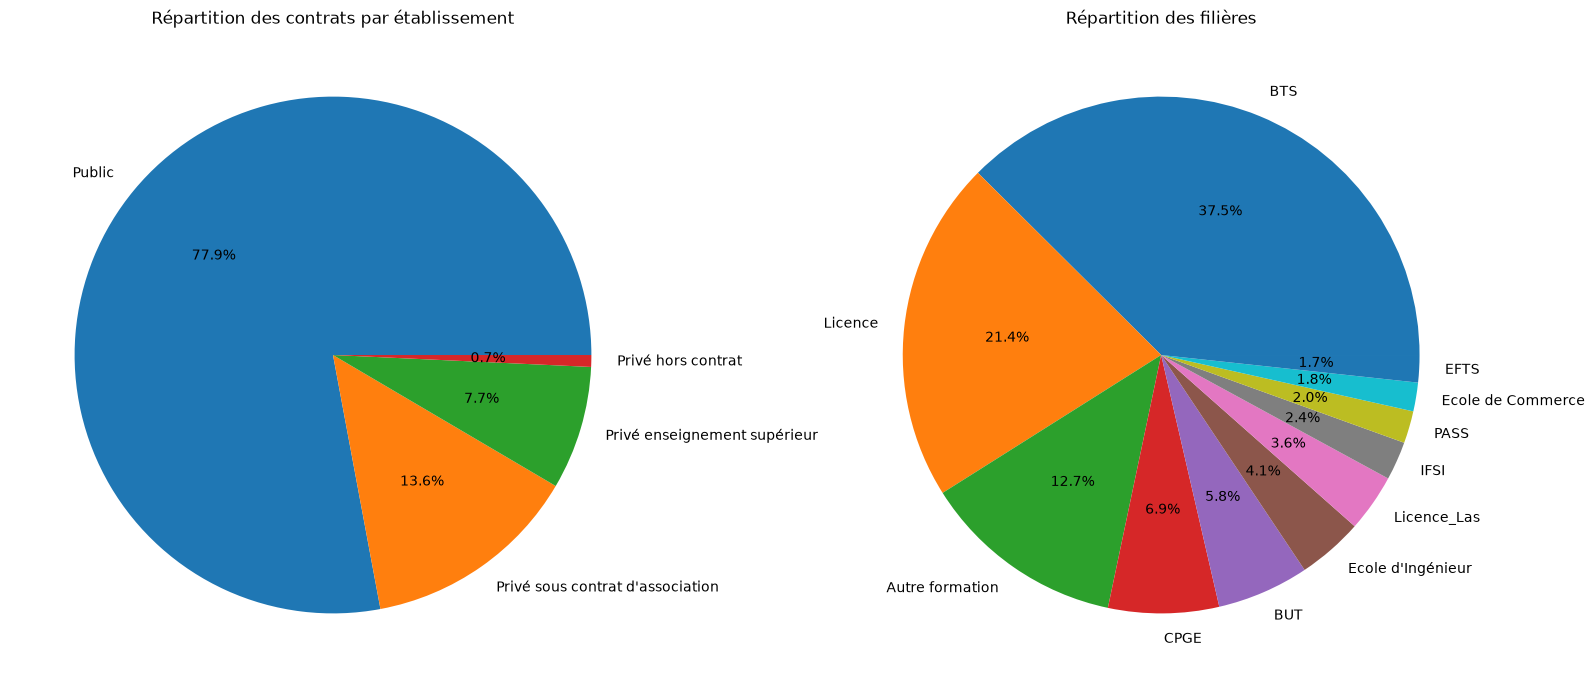

In [122]:
# subplot : Camembert de contrat_etab et celui de fili
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Camembert de contrat_etab
contrat_counts = df['contrat_etab'].value_counts()
axes[0].pie(contrat_counts, labels=contrat_counts.index, autopct='%1.1f%%')
axes[0].set_title('Répartition des contrats par établissement')

# Camembert de filière
filiere_counts = df['fili'].value_counts()
axes[1].pie(filiere_counts, labels=filiere_counts.index, autopct='%1.1f%%')
axes[1].set_title('Répartition des filières')

plt.tight_layout()
plt.show()

**Interprétation** : _à rédiger_

Parce qu'il y a beaucoup trop de modalités

**4.3** Boxplot de `voe_tot`. Est-il lisible ? Que faudrait-il faire ?

**Interprétation** : _à rédiger_

Bah, ne pas le faire, c'est pas grave, on peut le faire plus tard.

**4.4** Boxplots de `taux_acces_ens` selon `select_form`. Premier indice : le label « sélective » correspond-il vraiment à un taux d'accès plus faible ?

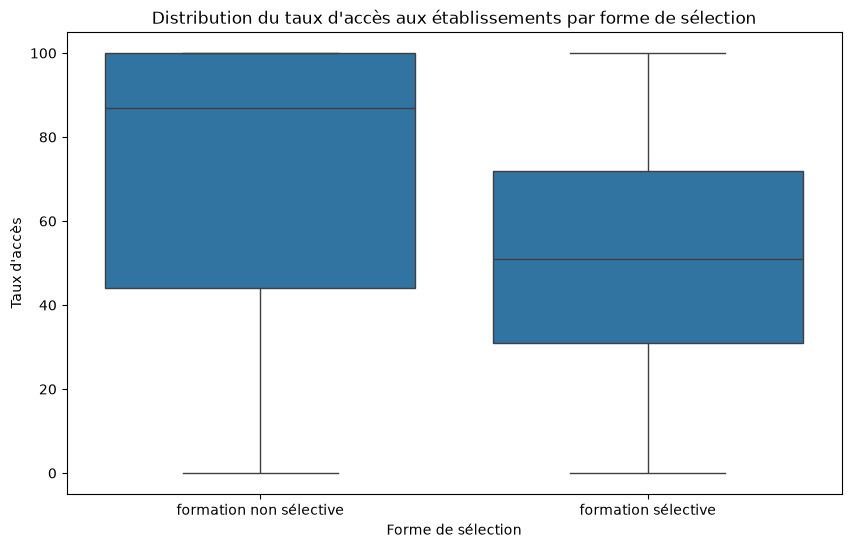

In [123]:
# Boxplots de `taux_acces_ens` selon `select_form`

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='select_form', y='taux_acces_ens')
plt.title('Distribution du taux d\'accès aux établissements par forme de sélection')
plt.xlabel('Forme de sélection')
plt.ylabel('Taux d\'accès')
plt.show()

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Graphiques », puis **push**.

# J1 après-midi — Approfondir les distributions

In [125]:
%pip install scipy 

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   --- ------------------------------------ 3.1/36.6 MB 21.3 MB/s eta 0:00:02
   --------- ------------------------------ 8.9/36.6 MB 22.6 MB/s eta 0:00:02
   --------------- ------------------------ 13.9/36.6 MB 23.1 MB/s eta 0:00:01
   ------------------- -------------------- 18.1/36.6 MB 22.0 MB/s eta 0:00:01
   ------------------------ --------------- 22.5/36.6 MB 22.0 MB/s eta 0:00:01
   ----------------------------- ---------- 27.3/36.6 MB 22.1 MB/s eta 0:00:01
   ---------------------------------- ----- 31.7/36.6 MB 21.9 MB/s eta 0:00:01
   ---------------------------------------  35.9/36.6 MB 21.7 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6 MB 20.5 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [126]:
from scipy import stats

## 5. Asymétrie et aplatissement

🎯 *Enquête* : la forme des variables décidera des outils à utiliser au J2 pour les relier à la sélectivité.

**5.1** Calculez la skewness et la kurtosis de `voe_tot`, `taux_acces_ens`, `capa_fin` et `pct_bours`. Classez-les de la plus symétrique à la plus asymétrique. Lesquelles faudra-t-il transformer avant de les relier à la sélectivité ?

In [134]:
#Calcul de skewness et kurtosis pour `voe_tot`, `taux_acces_ens`, capa_fin et prt_bours 
values = df[['voe_tot', 'taux_acces_ens']].dropna()
z = (values - values.mean()) / values.std(ddof=0)
x = (z ** 3).mean()
k = (z ** 4).mean() - 3
print(f"Skewness exp de voe_tot : {x}")
print(f"Kurtosis exp de voe_tot : {k}")

#Calcul de skewness et kurtosis pour `voe_tot`, `taux_acces_ens`, `capa_fin` et `pct_bours`
print('\n skewness theorique pour voe_tot : ', stats.skew(df['voe_tot']))
print('kurtosis theorique pour voe_tot : ', stats.kurtosis(df['voe_tot']))
print('\n skewness theorique pour taux_acces_ens : ', stats.skew(df['taux_acces_ens']))
print('kurtosis theorique pour taux_acces_ens : ', stats.kurtosis(df['taux_acces_ens']))
print('\n skewness theorique pour capa_fin : ', stats.skew(df['capa_fin']))
print('kurtosis theorique pour capa_fin : ', stats.kurtosis(df['capa_fin']))
print('\n skewness theorique pour pct_bours : ', stats.skew(df['pct_bours']))
print('kurtosis theorique pour pct_bours : ', stats.kurtosis(df['pct_bours']))

Skewness exp de voe_tot : voe_tot           4.076016
taux_acces_ens    0.026666
dtype: float64
Kurtosis exp de voe_tot : voe_tot           22.665707
taux_acces_ens    -1.136778
dtype: float64

 skewness theorique pour voe_tot :  4.077599753489567
kurtosis theorique pour voe_tot :  22.684445871668906

 skewness theorique pour taux_acces_ens :  nan
kurtosis theorique pour taux_acces_ens :  nan

 skewness theorique pour capa_fin :  12.698443822441655
kurtosis theorique pour capa_fin :  281.99996402835086

 skewness theorique pour pct_bours :  1.1276726054873019
kurtosis theorique pour pct_bours :  1.9172382027514425


In [ ]:
#Gra

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Asymétrie »

## 6. La loi normale

🎯 *Enquête* : peut-on utiliser sur la sélectivité les outils qui supposent une loi normale ?

**6.1** Vérifiez la règle 68-95-99,7 sur `taux_acces_ens`. La variable suit-elle une loi normale ? Quelle conséquence pour la suite de l'enquête ?

In [135]:
# Vérifiez la règle 68-95-99,7 sur `taux_acces_ens`

values = df['taux_acces_ens'].dropna()
mean = values.mean()
std_dev = values.std()
rule_68 = values[(values >= mean - std_dev) & (values <= mean + std_dev)]
rule_95 = values[(values >= mean - 2 * std_dev) & (values <= mean + 2 * std_dev)]
range_99_7 = values[(values >= mean - 3 * std_dev) & (values <= mean + 3 * std_dev)]
print(f"Pourcentage de valeurs dans la plage 68% : {len(rule_68) / len(values) * 100:.2f}%")
print(f"Pourcentage de valeurs dans la plage 95% : {len(rule_95) / len(values) * 100:.2f}%")
print(f"Pourcentage de valeurs dans la plage 99,7% : {len(range_99_7) / len(values) * 100:.2f}%")

Pourcentage de valeurs dans la plage 68% : 58.64%
Pourcentage de valeurs dans la plage 95% : 100.00%
Pourcentage de valeurs dans la plage 99,7% : 100.00%


**Interprétation** : _à rédiger_

On remarque que les valeurs sont assez centrées autours de 1x l'ecart type, et qu'on n'a pas de outliers. 
NON
Du coup, on devra trouver quelle loi suit notre jeu de données

> 💾 **Commit** : « Loi normale »

## 7. Les distributions réelles

🎯 *Enquête* : la demande (`voe_tot`) est une cause possible de sélectivité. Quelle échelle faudra-t-il utiliser pour la comparer au taux d'accès ?

**7.1** Tracez l'histogramme de `voe_tot`, puis celui de `log(voe_tot)`. Quelle loi reconnaissez-vous ? Quelle échelle utiliserez-vous au J2 pour relier la demande à la sélectivité ?

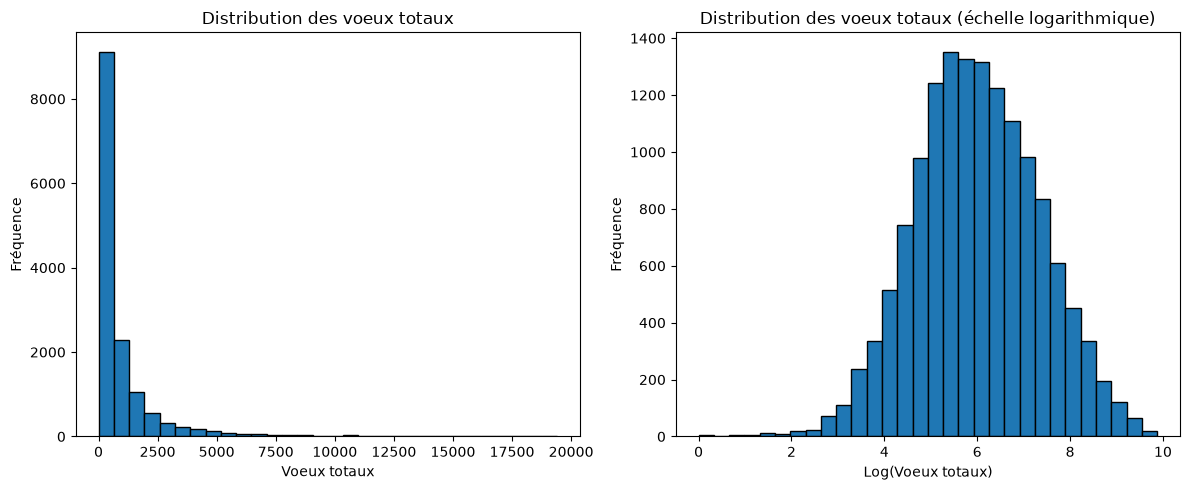

In [138]:
#sublot : Histogramme de voe_tot et log(voe_tot)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['voe_tot'], bins=30, edgecolor='black')
plt.xlabel('Voeux totaux')
plt.ylabel('Fréquence')
plt.title('Distribution des voeux totaux')

plt.subplot(1, 2, 2)
plt.hist(np.log(df['voe_tot']), bins=30, edgecolor='black')
plt.xlabel('Log(Voeux totaux)')
plt.ylabel('Fréquence')
plt.title('Distribution des voeux totaux (échelle logarithmique)')

plt.tight_layout()
plt.show()


**Interprétation** : _à rédiger_

Loi normale à l'echelle logarithmique/ Loi log-normale.

**7.2** Quelle part des vœux concentrent les 10 % et les 20 % de formations les plus demandées ? Est-ce une distribution de type Pareto ?

In [ ]:
# Part des vœux déposés dans les 10 % et 20 % des formations les plus demandées
voeux = df['voe_tot'].dropna().sort_values(ascending=False)
total_voeux = voeux.sum()

for part in (0.10, 0.20):
    n = int(np.ceil(part * len(voeux)))
    part_voeux = voeux.iloc[:n].sum() / total_voeux * 100
    print(f"Les {part:.0%} formations les plus demandées concentrent "
          f"{part_voeux:.1f}% des vœux.")

Les 10% formations les plus demandées concentrent 49.8% des vœux.
Les 20% formations les plus demandées concentrent 68.0% des vœux.


In [149]:
# recuperer Les 20% formations les plus demandées
top_20_percent = df.nlargest(int(0.20 * len(df)), 'voe_tot')

# Part des vœux déposés dans les 20 % des top_20_percent
total_voeux_20_percent = top_20_percent['voe_tot'].sum()
for part in (0.10, 0.20):
    n = int(np.ceil(part * len(top_20_percent)))
    part_voeux_20_percent = top_20_percent['voe_tot'].iloc[:n].sum() / total_voeux_20_percent * 100
    print(f"Les {part:.0%} formations les plus demandées dans le top 20% concentrent "
          f"{part_voeux_20_percent:.1f}% des vœux.")

Les 10% formations les plus demandées dans le top 20% concentrent 28.1% des vœux.
Les 20% formations les plus demandées dans le top 20% concentrent 44.0% des vœux.


**Interprétation** : _à rédiger_

Les 10% formations les plus demandées concentrent 49.8% des vœux.
Les 20% formations les plus demandées concentrent 68.0% des vœux.
La demande est donc très concentrée et donc se rapproche d'une distribution de Pareto.

> 💾 **Commit** : « Distributions »

## 8. Outliers

🎯 *Enquête* : les formations hors norme risquent de fausser les liens avec la sélectivité. Faut-il les garder ?

**8.1** Détectez les outliers de `capa_fin` avec la méthode IQR, puis avec le Z-score (|z| > 3). Comparez les nombres obtenus et expliquez l'écart.

In [141]:
# Outliers de capa_fin avec IQR puis avec Z-score (|z| > 3)

iqr = df['capa_fin'].quantile(0.75) - df['capa_fin'].quantile(0.25)
lower_bound = df['capa_fin'].quantile(0.25) - 1.5 * iqr
upper_bound = df['capa_fin'].quantile(0.75) + 1.5 * iqr
print(f"nombre d'outliers de capa_fin avec IQR : {len(df[(df['capa_fin'] < lower_bound) | (df['capa_fin'] > upper_bound)])}")

z_scores = (df['capa_fin'] - df['capa_fin'].mean()) / df['capa_fin'].std()
outliers_z = df[np.abs(z_scores) > 3]
print(f"nombre d'outliers de capa_fin avec Z-score : {len(outliers_z)}")

nombre d'outliers de capa_fin avec IQR : 1689
nombre d'outliers de capa_fin avec Z-score : 183


**Interprétation** : _à rédiger_

La méthode IQR détecte beaucoup plus d'outliers que le Z-score. Comme capa_fin est très asymétrique, le Z-score est moins adapté car il dépend fortement de la moyenne et de l'écart-type.

**8.2** Affichez les 10 plus grandes capacités. S'agit-il d'erreurs ou de valeurs réelles ? Que faites-vous ? Les garderez-vous pour étudier la sélectivité ?

In [145]:
df.nlargest(10, "capa_fin")[["g_ea_lib_vx", "lib_for_voe_ins", "capa_fin", "voe_tot", "taux_acces_ens"]]

,g_ea_lib_vx,lib_for_voe_ins,capa_fin,voe_tot,taux_acces_ens
10282,CNED,BTS - Services - Diététique et nutrition - Ent...,3400,1614,100.0
9035,CNED,BTS - Services - Communication - Entièrement e...,3200,1189,100.0
7184,CNED,BTS - Services - Commerce International - Enti...,2400,1822,100.0
8389,CNED,BTS - Services - Tourisme - Entièrement en dis...,2400,1022,100.0
8393,CNED,BTS - Services - Management Commercial Opérati...,2400,1224,100.0
5888,CNED,BTS - Services - Economie sociale familiale - ...,2000,541,100.0
7185,CNED,BTS - Services - Négociation et digitalisation...,2000,1089,100.0
9033,CNED,BTS - Services - Services et prestations des s...,2000,607,100.0
1907,Université Paris 1 Panthéon Sorbonne,Licence - Droit - Parcours Droit (EDS-IED) - E...,1500,4608,100.0
5889,CNED,BTS - Services - Comptabilité et gestion - Ent...,1500,687,100.0


**Interprétation** : _à rédiger_

Les plus grandes capacités correspondent surtout à des formations à distance (CNED). Ce ne sont pas forcément des erreurs, mais elles sont atypiques ; pour étudier la sélectivité, on peut les garder en les surveillant, ou utiliser des méthodes robustes/logarithmiques.

> 💾 **Commit** : « Outliers », puis **push**.

## 9. Analyse univariée en autonomie

🎯 *Enquête* : deux nouveaux suspects. Le profil social des admis et la région peuvent-ils jouer sur la sélectivité ?

Vous disposez maintenant de toute la méthode. Analysez **seuls** les deux variables suivantes, en suivant les étapes ci-dessous :
- une variable **quantitative** : `pct_bours` (part de boursiers parmi les admis, en %) ;
- une variable **qualitative** : `region_etab_aff` (région de l'établissement).

| Étape | Variable quantitative | Variable qualitative |
|---|---|---|
| 1. Comprendre | Ce qu'elle mesure, son unité, discrète ou continue | Nominale ou ordinale, liste des modalités |
| 2. Qualité | Valeurs manquantes, 0 suspects, bornes | Valeurs manquantes, modalités mal orthographiées |
| 3. Centre | Moyenne et médiane, comparées | Mode (et médiane si ordinale) |
| 4. Dispersion | σ, IQR, CV | Nombre de modalités, part de la modalité dominante |
| 5. Visualiser | Histogramme, boxplot | Diagramme en barres |
| 6. Forme | Skewness, kurtosis, QQ-plot : quelle loi ? | Répartition équilibrée ou concentrée, modalités rares |
| 7. Extrêmes | IQR ou Z-score selon la forme, puis inspection | — |
| 8. Conclure | Quel résumé, quels outils pour la suite ? | Quel regroupement, quel encodage pour la suite ? |

> Chaque chiffre s'interprète en une phrase.

### Variable quantitative : `pct_bours`

unité                       pourcentage
valeurs manquantes                    0
minimum                             0.0
maximum                           100.0
0 suspects                         1882
moyenne                       22.267261
médiane                            20.0
écart-type                    17.767732
IQR                                23.0
coefficient de variation       0.797931
skewness                       1.127673
kurtosis                       1.917238
outliers IQR                        338
dtype: object

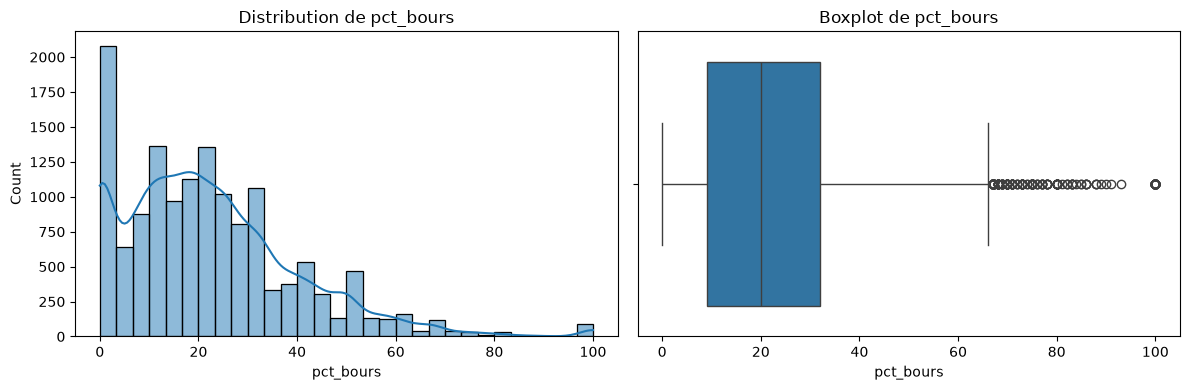

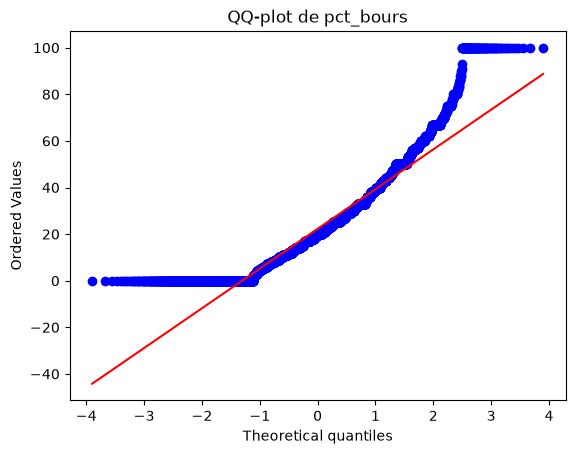

In [153]:
s = df["pct_bours"].dropna()

q1 = s.quantile(0.25)

q3 = s.quantile(0.75)

iqr = q3 - q1

borne_haute = q3 + 1.5 * iqr

analyse_pct_bours = pd.Series({

    "unité": "pourcentage",

    "valeurs manquantes": df["pct_bours"].isna().sum(),

    "minimum": s.min(),

    "maximum": s.max(),

    "0 suspects": (s == 0).sum(),

    "moyenne": s.mean(),

    "médiane": s.median(),

    "écart-type": s.std(),

    "IQR": iqr,

    "coefficient de variation": s.std() / s.mean(),

    "skewness": stats.skew(s),

    "kurtosis": stats.kurtosis(s),

    "outliers IQR": ((s < q1 - 1.5 * iqr) | (s > borne_haute)).sum()

})

display(analyse_pct_bours)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(s, bins=30, kde=True, ax=axes[0])

axes[0].set_title("Distribution de pct_bours")

sns.boxplot(x=s, ax=axes[1])

axes[1].set_title("Boxplot de pct_bours")

plt.tight_layout()

plt.show()
 
stats.probplot(s, dist="norm", plot=plt)

plt.title("QQ-plot de pct_bours")

plt.show()

 

**Analyse** : _à rédiger_

pct_bours mesure la part de boursiers parmi les admis, en pourcentage. La médiane est autour de 20 %, la moyenne autour de 22 %, et la distribution est asymétrique à droite : quelques formations ont une part très élevée de boursiers. Pour la suite, on peut garder la variable quantitative, mais l'interpréter avec prudence car elle n'est pas parfaitement normale.

### Variable qualitative : `region_etab_aff`

valeurs manquantes                        97
nombre de modalités                       18
modalité dominante             Ile-de-France
part modalité dominante (%)         19.01095
dtype: object

region_etab_aff
Ile-de-France                 2691
Auvergne-Rhône-Alpes          1730
Hauts-de-France               1272
Occitanie                     1218
Nouvelle Aquitaine            1162
Grand-Est                     1150
Provence-Alpes-Côte d'Azur     973
Pays-de-la-Loire               840
Bretagne                       758
Normandie                      631
Bourgogne-Franche-Comté        580
Centre                         461
Réunion                        246
Guadeloupe                     130
Martinique                     127
NaN                             97
Corse                           75
Guyane                          68
Mayotte                         43
Name: count, dtype: int64

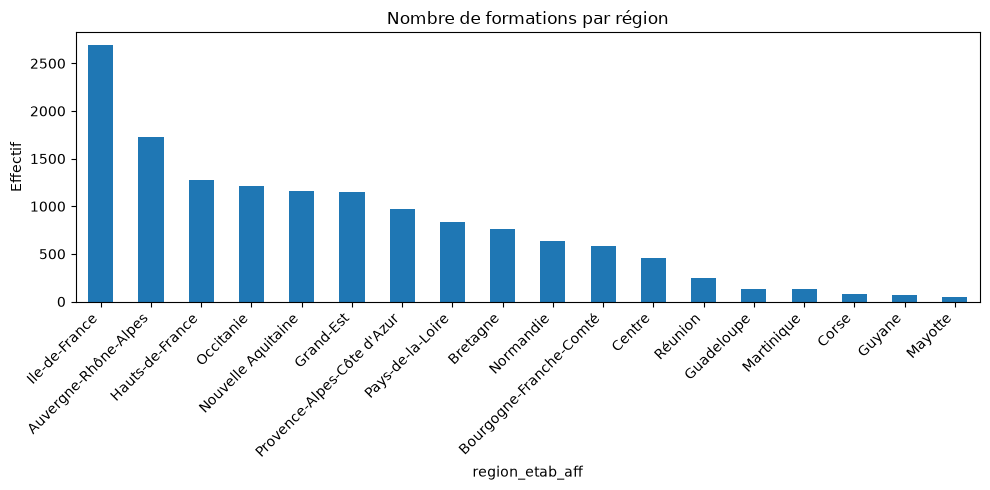

In [154]:
region = df["region_etab_aff"]
resume_region = pd.Series({
    "valeurs manquantes": region.isna().sum(),
    "nombre de modalités": region.nunique(),
    "modalité dominante": region.mode().iloc[0],
    "part modalité dominante (%)": region.value_counts(normalize=True).iloc[0] * 100
})
display(resume_region)
display(region.value_counts(dropna=False))
 
plt.figure(figsize=(10, 5))
region.value_counts().plot(kind="bar")
plt.title("Nombre de formations par région")
plt.ylabel("Effectif")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Analyse** : _à rédiger_

region_etab_aff est une variable qualitative nominale. Les formations sont concentrées dans certaines régions, notamment l'Ile-de-France et Auvergne-Rhône-Alpes. Pour la suite, on pourra garder les grandes régions et éventuellement regrouper les modalités rares.

> 💾 **Commit** : « Analyse univariée », puis **push**.

## 📝 Synthèse J1 — Ce qu'on sait sur la sélectivité

- À quoi ressemble la sélectivité d'une formation typique ? Les formations sont-elles proches ou très différentes ?
- Quels premiers indices avez-vous trouvés sur ce qui la fait varier ?
- Quelles variables faudra-t-il transformer pour la suite, et pourquoi ?

4 à 6 lignes.

**Synthèse** : _à rédiger_

Une formation typique a un taux d'accès proche de 54 %, donc environ un candidat sur deux reçoit une proposition. Les formations sont très différentes entre elles : certaines sont très ouvertes, d'autres beaucoup plus sélectives. La demande (voe_tot) est extrêmement concentrée et asymétrique, donc il faudra souvent utiliser log(voe_tot). Le label « formation sélective » correspond bien à des taux d'accès plus faibles. Les variables de taille et de demande devront être étudiées ensemble, car une formation très demandée peut aussi avoir beaucoup de places.

> 💾 **Commit** : « Synthèse J1 », puis **push**.

# J2 matin — Mettre en pratique les fondements mathématiques de la corrélation

## 10. Covariance

🎯 *Enquête* : on passe au bivarié. On apprend d'abord à mesurer un lien sur un couple simple (capacité × vœux), avant de l'appliquer à la sélectivité.

**10.1** Tracez le nuage de points de `voe_tot` en fonction de `capa_fin`. Calculez leur covariance à la main (produits des écarts), puis avec pandas.

**Interprétation** : _à rédiger_

**10.2** Recalculez la covariance avec la capacité exprimée en centaines de places. Que constatez-vous ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Covariance »

## 11. Corrélation de Pearson

🎯 *Enquête* : première mesure chiffrée du lien entre la demande et la sélectivité.

**11.1** Calculez r entre `capa_fin` et `voe_tot` à la main (covariance / produit des écarts-types), puis avec pandas. Faites de même pour `voe_tot` et `taux_acces_ens`. Que dit ce second coefficient sur la sélectivité ?

**Interprétation** : _à rédiger_

**11.2** Les conditions de Pearson sont-elles respectées ? Recalculez r entre `log(capa_fin)` et `log(voe_tot)` (en excluant les valeurs nulles).

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Pearson »

## 12. Corrélation de Spearman

🎯 *Enquête* : le lien demande × sélectivité est-il sous-estimé par Pearson ?

**12.1** Calculez Spearman pour les deux couples de la question 11.1. Comparez avec Pearson et expliquez les écarts.

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Spearman »

## 13. Tests d'hypothèse

🎯 *Enquête* : le lien entre demande et sélectivité est-il réel, ou dû au hasard ? Et quel coefficient retenir pour la suite ?

**13.1** Testez la normalité de `taux_acces_ens` avec Shapiro-Wilk et Anderson-Darling, sur un échantillon de 50 formations puis sur toutes. Formulez H0 et concluez. Quel coefficient de corrélation retiendrez-vous pour la suite de l'enquête ?

**Interprétation** : _à rédiger_

**13.2** Testez la corrélation entre `voe_tot` et `taux_acces_ens` (Spearman). Formulez H0, donnez la p-value et concluez. Le lien est-il fort pour autant ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Tests », puis **push**.

# J2 après-midi — Approfondir les relations quantitatives

## 14. Corrélation partielle

🎯 *Enquête* : le lien entre demande et sélectivité tient-il à capacité égale ?

**14.1** Calculez la corrélation entre `log(voe_tot)` et `taux_acces_ens`, puis la corrélation partielle en contrôlant `log(capa_fin)`. Que concluez-vous ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Corrélation partielle »

## 15. A/B testing

🎯 *Enquête* : un lien observé suffit-il à affirmer qu'un facteur *cause* la sélectivité ?

**15.1** Au J3, vous verrez que les formations privées ont un taux d'accès plus élevé que les publiques. Peut-on en conclure que le statut privé *rend* une formation moins sélective ? Quelle expérience faudrait-il pour le prouver, et est-elle possible ici ?

**Interprétation** : _à rédiger_

**15.2** Reprenez la simulation de la démo avec 500 visiteurs, puis 20 000. Une version B qui fait passer le taux d'achat de 20 % à 22 %. L'effet est-il détecté dans les deux cas ? Pourquoi ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « A/B testing »

## 16. Matrice de corrélation

🎯 *Enquête* : vue d'ensemble. Quelles variables quantitatives sont liées à la sélectivité, et lesquelles disent la même chose ?

**16.1** Tracez la heatmap des corrélations de Spearman entre `capa_fin`, `voe_tot`, `acc_tot`, `taux_acces_ens`, `pct_bours`, `pct_f`, `pct_tb`. Quelles variables sont redondantes ? Quelles variables sont les meilleures candidates pour expliquer la sélectivité ?

**Interprétation** : _à rédiger_

## 17. Régression simple

🎯 *Enquête* : le niveau scolaire des admis explique-t-il la sélectivité, et dans quelle mesure ?

**17.1** Régressez `taux_acces_ens` sur `pct_tb` (part de mentions très bien parmi les admis). Donnez la pente, le R², et tracez les résidus. Les mentions TB expliquent-elles la sélectivité ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Régression », puis **push**.

## 📝 Synthèse J2 — Ce qu'on sait sur la sélectivité

- Quelles variables quantitatives sont liées à la sélectivité, avec quelle force ?
- Le lien avec la demande tient-il quand on contrôle la taille ?
- Peut-on parler de causes ? Pourquoi ?

4 à 6 lignes.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Synthèse J2 », puis **push**.

# J3 matin — Comprendre les fondements du bivarié qualitatif

## 18. Table de contingence et Chi²

🎯 *Enquête* : le label « formation sélective » dépend-il du statut de l'établissement ?

**18.1** Croisez `select_form` et `contrat_etab` : table des effectifs, puis fréquences conditionnelles par statut.

**Interprétation** : _à rédiger_

**18.2** Faites le test du Chi² d'indépendance (H0, effectifs théoriques, p-value), puis calculez le V de Cramér et les résidus standardisés.

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Chi² »

## 19. Quantitatif × qualitatif

🎯 *Enquête* : la sélectivité varie-t-elle selon le statut (public / privé) et selon la filière ?

**19.1** Le `taux_acces_ens` diffère-t-il entre formations publiques et privées ? Boxplot, Student (Welch) et Mann-Whitney.

**Interprétation** : _à rédiger_

**19.2** Le `taux_acces_ens` diffère-t-il selon la filière (`fili`) ? ANOVA et Kruskal-Wallis. Quelles filières sont les plus sélectives ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « Quanti × quali », puis **push**.

# J3 après-midi — Introduire le multivarié

## 20. ACP

🎯 *Enquête* : on rassemble toutes les variables. Où se place la sélectivité parmi elles ?

**20.1** Faites une ACP sur `log(capa_fin)`, `log(voe_tot)`, `taux_acces_ens`, `pct_bours`, `pct_f`, `pct_tb` (centrées-réduites). Quelle part de variance portent les deux premiers axes ? Interprétez-les à partir des contributions. Où se place `taux_acces_ens` sur ces axes ?

**Interprétation** : _à rédiger_

> 💾 **Commit** : « ACP », puis **push**.

## 🏁 Conclusion de l'enquête

Répondez à la question : **qu'est-ce qui rend une formation sélective sur Parcoursup ?**

- Les facteurs retenus, classés par importance, chacun appuyé par un chiffre du TP.
- Les pistes écartées.
- Les limites : ce que vos analyses ne permettent pas d'affirmer.

10 à 15 lignes. Cette conclusion compte dans la note du TP.

**Synthèse** : _à rédiger_

> 💾 **Commit** : « Conclusion de l'enquête », puis **push**.